<a href="https://colab.research.google.com/github/Afrinjahan/machine_learning/blob/main/ML_Lab05_Polynomial_Regularization.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Machine Learning — Lab Sheet 05
## Polynomial Regression & Regularization — Ridge and Lasso (Auto MPG Dataset)

**Brahmaputra International University | Department of CSE**

**Objectives:**
- Implement Polynomial Regression to capture non-linear relationships.
- Observe overfitting as polynomial degree increases, using training vs. test error.
- Implement Ridge (L2) and Lasso (L1) regularization to control model complexity.
- Understand how Lasso can perform automatic feature selection.
- Compare unregularized, Ridge, and Lasso models on the same real dataset.

**Dataset:** Same real Auto MPG dataset used in Lab 4 (392 cars after removing missing horsepower).

### 0. Setup

In [ ]:
!pip install -q scikit-learn pandas matplotlib


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score

df = pd.read_csv("https://raw.githubusercontent.com/mwaskom/seaborn-data/master/mpg.csv")
df = df.dropna(subset=['horsepower']).reset_index(drop=True)
print(df.shape)


(392, 9)


### 1. Polynomial Regression (Horsepower → MPG)

In Lab 4, the residual plot for horsepower vs. MPG showed a curved pattern, suggesting the true relationship is not linear. We now fit polynomial models of increasing degree to the same data.

In [ ]:
X = df[['horsepower']].values
y = df['mpg'].values
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

for degree in [1, 2, 3]:
    poly = PolynomialFeatures(degree=degree)
    X_train_poly = poly.fit_transform(X_train)
    X_test_poly = poly.transform(X_test)
    model = LinearRegression().fit(X_train_poly, y_train)
    y_pred = model.predict(X_test_poly)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2 = r2_score(y_test, y_pred)
    print(f'Degree {degree}: RMSE={rmse:.3f}, R2={r2:.3f}')


Degree 1: RMSE=4.707, R2=0.566
Degree 2: RMSE=4.291, R2=0.639
Degree 3: RMSE=4.297, R2=0.638


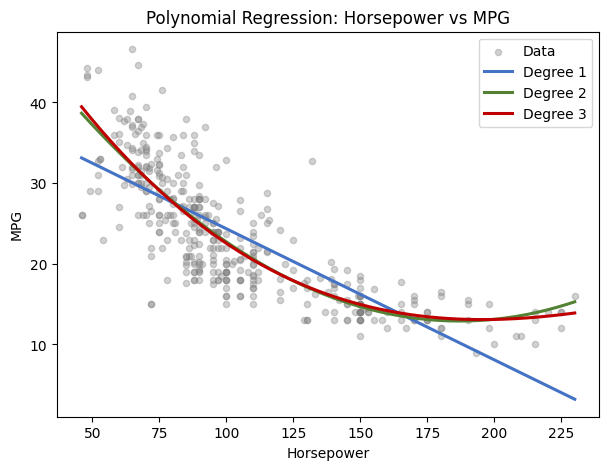

In [ ]:
fig, ax = plt.subplots(figsize=(7, 5))
ax.scatter(X, y, alpha=0.35, color='gray', s=20, label='Data')
x_line = np.linspace(X.min(), X.max(), 200).reshape(-1,1)
colors = {1: '#4472C4', 2: '#548235', 3: '#C00000'}
for degree in [1, 2, 3]:
    poly = PolynomialFeatures(degree=degree)
    Xtr_p = poly.fit_transform(X_train)
    model = LinearRegression().fit(Xtr_p, y_train)
    y_line = model.predict(poly.transform(x_line))
    ax.plot(x_line, y_line, color=colors[degree], linewidth=2.2, label=f'Degree {degree}')
ax.set_title('Polynomial Regression: Horsepower vs MPG')
ax.set_xlabel('Horsepower'); ax.set_ylabel('MPG'); ax.legend()
plt.show()


**Observation:** Degree 2 clearly improves over degree 1 (RMSE drops from 4.707 to 4.291). Degree 3 gives virtually no further improvement — an early sign of diminishing returns before overfitting.

### 2. Overfitting: RMSE vs. Polynomial Degree

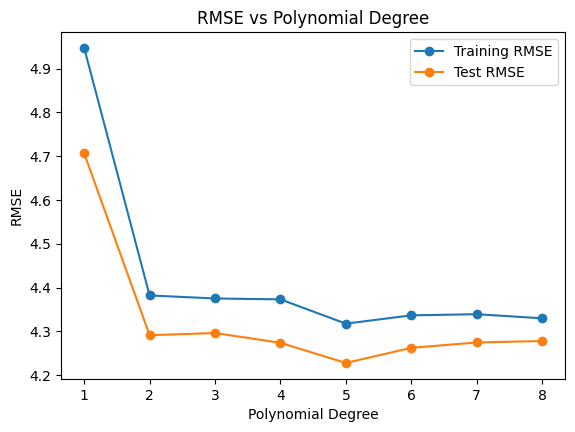

In [ ]:
degrees = list(range(1, 9))
train_rmse, test_rmse = [], []
for d in degrees:
    poly = PolynomialFeatures(degree=d)
    Xtr_p = poly.fit_transform(X_train)
    Xte_p = poly.transform(X_test)
    m = LinearRegression().fit(Xtr_p, y_train)
    train_rmse.append(np.sqrt(np.mean((m.predict(Xtr_p) - y_train)**2)))
    test_rmse.append(np.sqrt(np.mean((m.predict(Xte_p) - y_test)**2)))

fig, ax = plt.subplots(figsize=(6.5, 4.5))
ax.plot(degrees, train_rmse, marker='o', label='Training RMSE')
ax.plot(degrees, test_rmse, marker='o', label='Test RMSE')
ax.set_xlabel('Polynomial Degree'); ax.set_ylabel('RMSE'); ax.legend()
ax.set_title('RMSE vs Polynomial Degree')
plt.show()


**Observation:** Training RMSE keeps decreasing as degree increases, but test RMSE flattens and then rises at higher degrees — the classic signature of overfitting, which regularization is designed to control.

### 3. Preparing Multiple Features for Regularization

Regularization is most useful when features are correlated (multicollinearity), since unregularized regression can produce unstable, extreme coefficients in that situation.

In [ ]:
features = ['cylinders','displacement','horsepower','weight','acceleration','model_year']
corr = df[features].corr()
print(corr.round(2))


              cylinders  displacement  horsepower  weight  acceleration  \
cylinders          1.00          0.95        0.84    0.90         -0.50   
displacement       0.95          1.00        0.90    0.93         -0.54   
horsepower         0.84          0.90        1.00    0.86         -0.69   
weight             0.90          0.93        0.86    1.00         -0.42   
acceleration      -0.50         -0.54       -0.69   -0.42          1.00   
model_year        -0.35         -0.37       -0.42   -0.31          0.29   

              model_year  
cylinders          -0.35  
displacement       -0.37  
horsepower         -0.42  
weight             -0.31  
acceleration        0.29  
model_year          1.00  


### 4. Ridge Regression (L2 Regularization)

In [ ]:
X_multi = df[features].values
y = df['mpg'].values
Xtr, Xte, ytr, yte = train_test_split(X_multi, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
Xtr_s = scaler.fit_transform(Xtr)
Xte_s = scaler.transform(Xte)

lr = LinearRegression().fit(Xtr_s, ytr)
ridge = Ridge(alpha=1.0).fit(Xtr_s, ytr)

print('Linear:', dict(zip(features, np.round(lr.coef_, 3))))
print('Ridge :', dict(zip(features, np.round(ridge.coef_, 3))))
print(f'Linear R2: {r2_score(yte, lr.predict(Xte_s)):.3f}')
print(f'Ridge  R2: {r2_score(yte, ridge.predict(Xte_s)):.3f}')


Linear: {'cylinders': np.float64(-0.197), 'displacement': np.float64(0.105), 'horsepower': np.float64(-0.087), 'weight': np.float64(-5.51), 'acceleration': np.float64(0.174), 'model_year': np.float64(2.757)}
Ridge : {'cylinders': np.float64(-0.207), 'displacement': np.float64(-0.009), 'horsepower': np.float64(-0.165), 'weight': np.float64(-5.336), 'acceleration': np.float64(0.129), 'model_year': np.float64(2.736)}
Linear R2: 0.794
Ridge  R2: 0.794


**Real finding:** unregularized linear regression gives `displacement` a *positive* coefficient despite displacement clearly reducing MPG in practice — a sign of coefficient instability from multicollinearity. Ridge pulls it back toward a small negative value, a more physically sensible result.

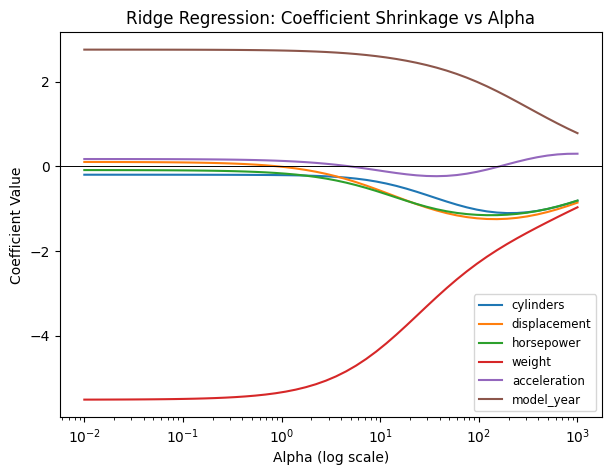

In [ ]:
alphas = np.logspace(-2, 3, 50)
coefs = []
for a in alphas:
    m = Ridge(alpha=a).fit(Xtr_s, ytr)
    coefs.append(m.coef_)
coefs = np.array(coefs)

fig, ax = plt.subplots(figsize=(7, 5))
for i, f in enumerate(features):
    ax.plot(alphas, coefs[:, i], label=f)
ax.set_xscale('log')
ax.set_title('Ridge Regression: Coefficient Shrinkage vs Alpha')
ax.set_xlabel('Alpha (log scale)'); ax.set_ylabel('Coefficient Value')
ax.axhline(0, color='black', linewidth=0.7)
ax.legend(fontsize=8.5)
plt.show()


### 5. Lasso Regression (L1 Regularization)

In [ ]:
lasso = Lasso(alpha=0.5).fit(Xtr_s, ytr)
print('Lasso :', dict(zip(features, np.round(lasso.coef_, 3))))
print(f'Lasso R2: {r2_score(yte, lasso.predict(Xte_s)):.3f}')


Lasso : {'cylinders': np.float64(-0.0), 'displacement': np.float64(-0.144), 'horsepower': np.float64(-0.237), 'weight': np.float64(-5.019), 'acceleration': np.float64(0.0), 'model_year': np.float64(2.379)}
Lasso R2: 0.805


**Real finding:** Lasso sets both `cylinders` and `acceleration` coefficients to exactly 0.0 — it has automatically decided these features add nothing once weight, horsepower, displacement, and model_year are accounted for. Lasso also achieves the best R² of the three models (0.805).

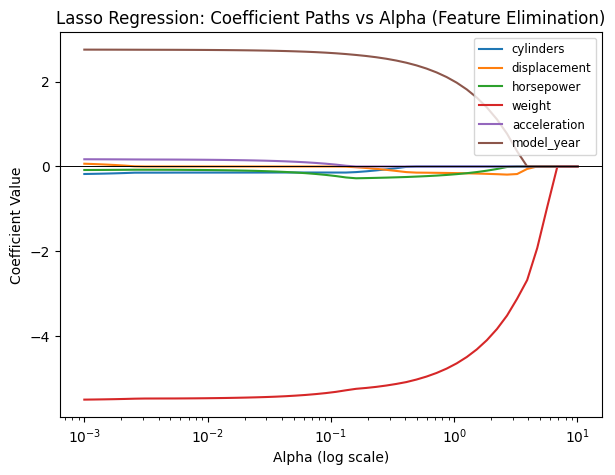

In [ ]:
alphas_l = np.logspace(-3, 1, 50)
coefs_l = []
for a in alphas_l:
    m = Lasso(alpha=a, max_iter=10000).fit(Xtr_s, ytr)
    coefs_l.append(m.coef_)
coefs_l = np.array(coefs_l)

fig, ax = plt.subplots(figsize=(7, 5))
for i, f in enumerate(features):
    ax.plot(alphas_l, coefs_l[:, i], label=f)
ax.set_xscale('log')
ax.set_title('Lasso Regression: Coefficient Paths vs Alpha (Feature Elimination)')
ax.set_xlabel('Alpha (log scale)'); ax.set_ylabel('Coefficient Value')
ax.axhline(0, color='black', linewidth=0.7)
ax.legend(fontsize=8.5)
plt.show()


### 6. Side-by-Side Comparison

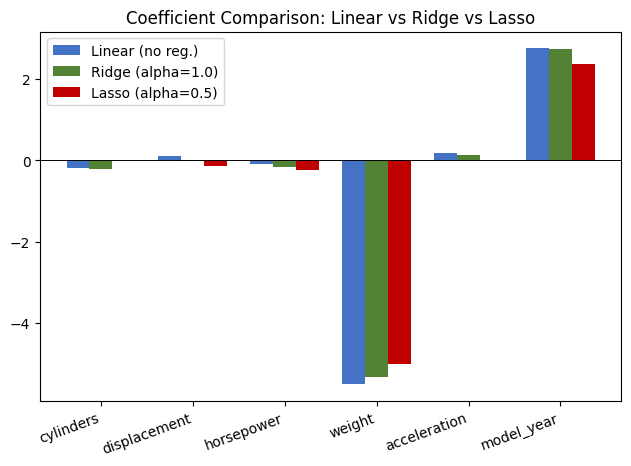

In [ ]:
x_pos = np.arange(len(features))
width = 0.25
fig, ax = plt.subplots(figsize=(7.5, 4.8))
ax.bar(x_pos - width, lr.coef_, width, label='Linear (no reg.)', color='#4472C4')
ax.bar(x_pos, ridge.coef_, width, label='Ridge (alpha=1.0)', color='#548235')
ax.bar(x_pos + width, lasso.coef_, width, label='Lasso (alpha=0.5)', color='#C00000')
ax.set_xticks(x_pos); ax.set_xticklabels(features, rotation=20, ha='right')
ax.set_title('Coefficient Comparison: Linear vs Ridge vs Lasso')
ax.axhline(0, color='black', linewidth=0.7)
ax.legend()
plt.show()


| Model | R² Score | RMSE | Notable Behavior |
|---|---|---|---|
| Linear (no regularization) | 0.794 | 3.241 | Unstable sign on `displacement` due to multicollinearity |
| Ridge (alpha=1.0) | 0.794 | 3.246 | Shrinks all coefficients smoothly, fixes sign instability |
| Lasso (alpha=0.5) | 0.805 | 3.158 | Zeroes out `cylinders` and `acceleration` entirely |

### 7. Lab Exercise (To Be Submitted)

1. Try Ridge and Lasso with alpha values of 0.01, 0.1, 10, and 100. Report R² and RMSE for each, and describe the trend as alpha increases.
2. At what approximate alpha value does Lasso first set a coefficient to exactly zero? Use the Lasso coefficient path plot (or your own alpha sweep) to estimate this and name which feature drops out first.
3. Fit a degree-2 polynomial model on the multi-feature dataset (all 6 features) combined with Ridge regularization. Compare its R² to the plain (degree-1) Ridge model from Section 4.
4. In your own words (150–200 words, in a new Markdown cell), explain when you would prefer Lasso over Ridge for a real project, using evidence from this lab's results.
5. Save your completed notebook and submit it (.ipynb) with all code, outputs, plots, and written answers.